# EDA — Can This Mix? Drug-Drug Interaction Dataset
**Team:** Devin Farrell · Navizar Maestiano Lubis · Zacky Satria Nugraha  
**Course:** COMP6577001 — Machine Learning  

This notebook performs Exploratory Data Analysis on the raw `db_drug_interactions.csv` dataset before any preprocessing or model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

BLUE   = '#4C72B0'
RED    = '#C44E52'
COLORS = [BLUE, RED, '#55A868', '#DD8452', '#8172B3',
          '#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD',
          '#4C72B0', '#DD8452', '#55A868']

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load & Basic Overview

In [2]:
df = pd.read_csv('db_drug_interactions.csv')

print('=== DATASET OVERVIEW ===')
print(f'Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns       : {df.columns.tolist()}')
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== SAMPLE ROWS ===')
df.head()

=== DATASET OVERVIEW ===
Shape         : 191,541 rows × 3 columns
Columns       : ['Drug 1', 'Drug 2', 'Interaction Description']

=== MISSING VALUES ===
Drug 1                     0
Drug 2                     0
Interaction Description    0
dtype: int64

=== SAMPLE ROWS ===


,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...


In [3]:
# Drug universe stats
all_drugs   = pd.concat([df['Drug 1'], df['Drug 2']])
n_unique    = all_drugs.nunique()
n_possible  = n_unique * (n_unique - 1) // 2          # nC2 unordered pairs
coverage_pct = len(df) / n_possible * 100

print('=== DRUG UNIVERSE ===')
print(f'Unique drugs in Drug 1 : {df["Drug 1"].nunique():,}')
print(f'Unique drugs in Drug 2 : {df["Drug 2"].nunique():,}')
print(f'Total unique drugs     : {n_unique:,}')
print()
print('=== PAIR COVERAGE ===')
print(f'Documented interactions : {len(df):,}')
print(f'Possible unique pairs   : {n_possible:,}')
print(f'Dataset coverage        : {coverage_pct:.2f}%')
print()
print('→ The remaining ~87% of possible drug pairs have NO documented interaction')
print('  and will form our synthetic negative (Class 0) samples in the next step.')

=== DRUG UNIVERSE ===
Unique drugs in Drug 1 : 1,634
Unique drugs in Drug 2 : 1,606
Total unique drugs     : 1,701

=== PAIR COVERAGE ===
Documented interactions : 191,541
Possible unique pairs   : 1,445,850
Dataset coverage        : 13.25%

→ The remaining ~87% of possible drug pairs have NO documented interaction
  and will form our synthetic negative (Class 0) samples in the next step.


---
## 2. Class Structure — Only Positives in Raw Data

The raw dataset contains **only documented adverse interactions (Class 1)**. This is a critical observation: we must construct Class 0 (safe pairs) synthetically during preprocessing.

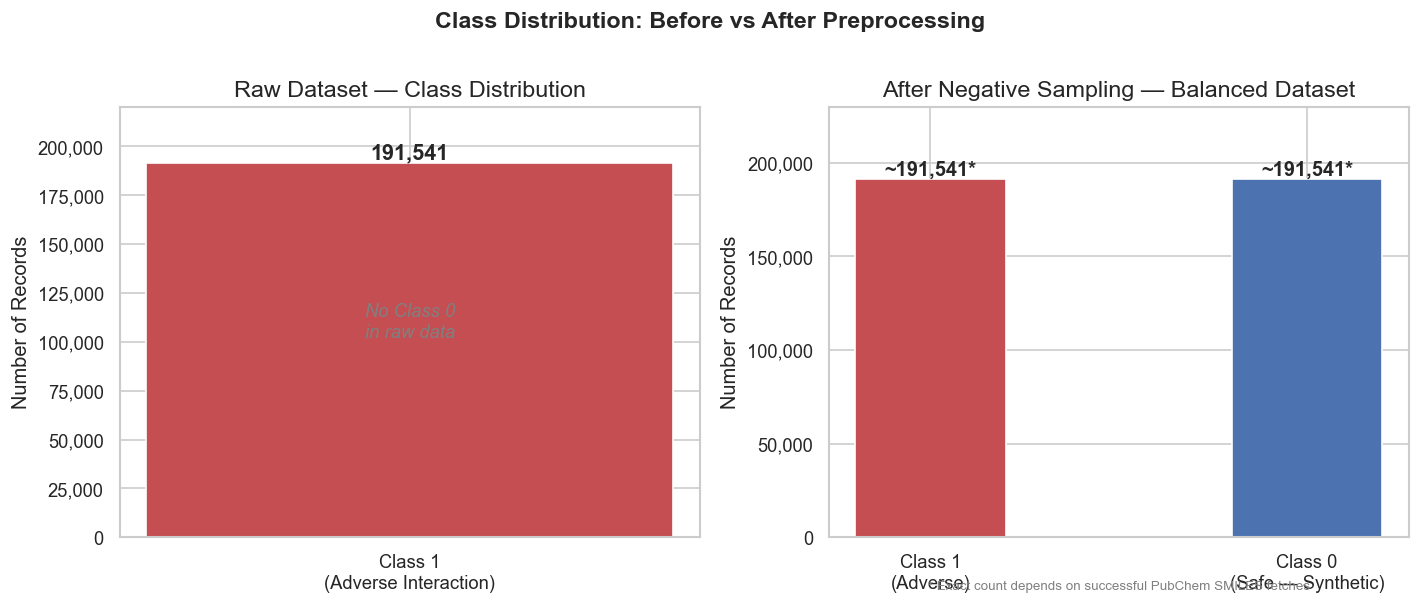

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: raw dataset (all positive)
ax = axes[0]
ax.bar(['Class 1\n(Adverse Interaction)'], [len(df)], color=RED, width=0.4, edgecolor='white')
ax.set_title('Raw Dataset — Class Distribution')
ax.set_ylabel('Number of Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.annotate(f'{len(df):,}', xy=(0, len(df)), ha='center', va='bottom',
            fontweight='bold', fontsize=13)
ax.set_ylim(0, len(df) * 1.15)
ax.text(0.5, 0.5, 'No Class 0\nin raw data',
        transform=ax.transAxes, ha='center', va='center',
        fontsize=11, color='grey', style='italic')

# Right: after balanced negative sampling
ax2 = axes[1]
ax2.bar(['Class 1\n(Adverse)', 'Class 0\n(Safe — Synthetic)'],
        [len(df), len(df)], color=[RED, BLUE], width=0.4, edgecolor='white')
ax2.set_title('After Negative Sampling — Balanced Dataset')
ax2.set_ylabel('Number of Records')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate([len(df), len(df)]):
    ax2.annotate(f'~{v:,}*', xy=(i, v), ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
ax2.set_ylim(0, len(df) * 1.2)
ax2.text(0.5, -0.12, '* Exact count depends on successful PubChem SMILES fetches',
         transform=ax2.transAxes, ha='center', fontsize=8, color='grey')

plt.suptitle('Class Distribution: Before vs After Preprocessing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Drug Frequency Analysis

Which drugs appear most frequently as interaction partners? High-frequency drugs are likely broad-spectrum enzyme inducers/inhibitors (e.g., Phenobarbital, Rifampicin).

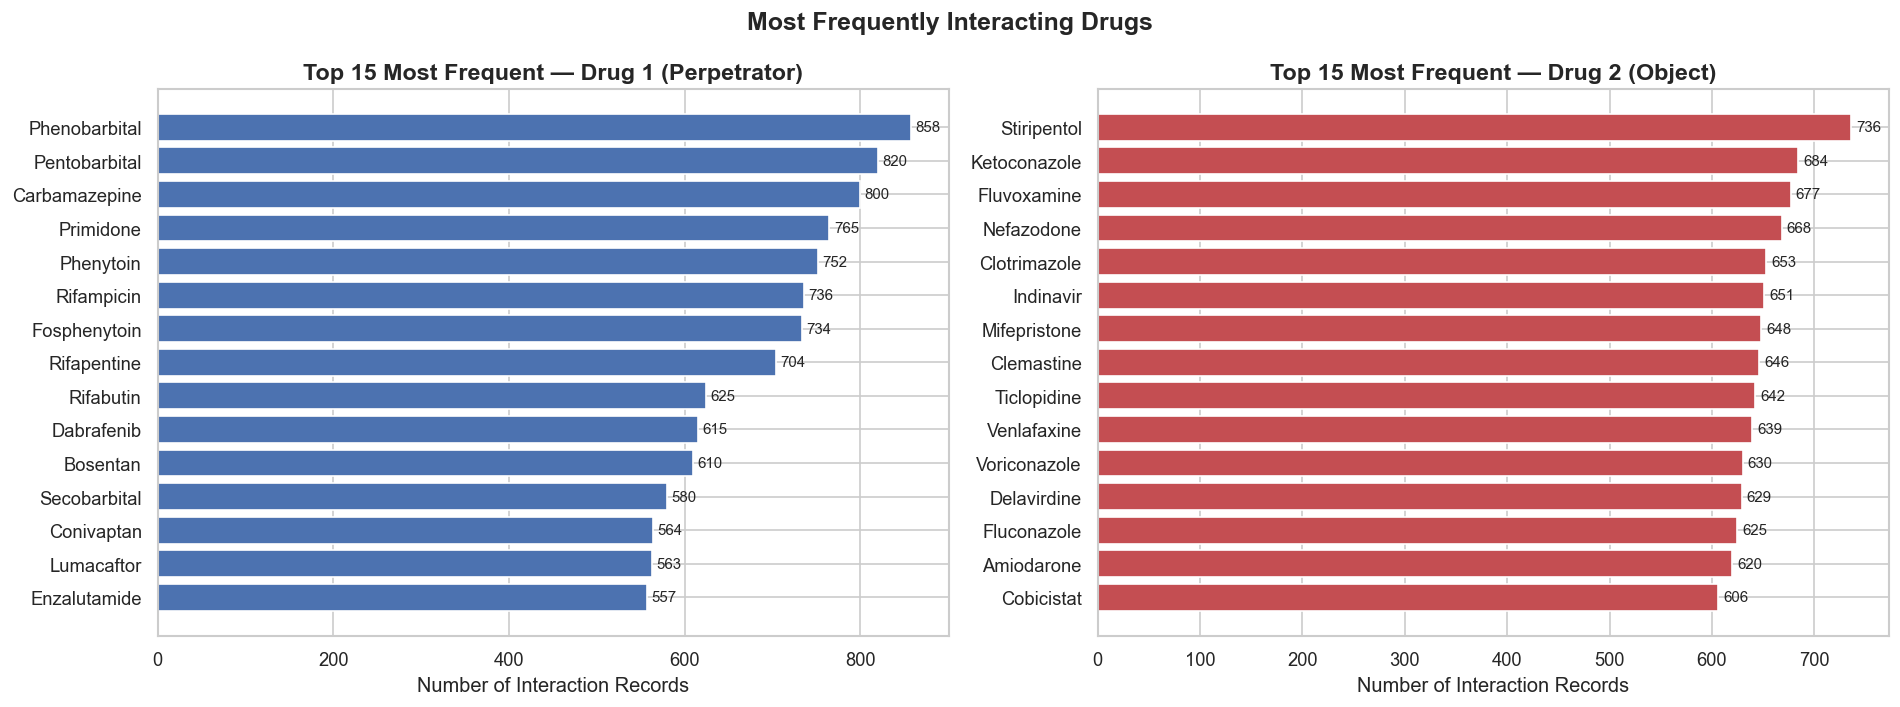

Insight: Top Drug 1 drugs (Phenobarbital, Carbamazepine, Rifampicin) are
well-known CYP450 enzyme inducers, explaining their high interaction counts.


In [5]:
top_n = 15
top_d1 = df['Drug 1'].value_counts().head(top_n)
top_d2 = df['Drug 2'].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in zip(
        axes,
        [top_d1, top_d2],
        [f'Top {top_n} Most Frequent — Drug 1 (Perpetrator)',
         f'Top {top_n} Most Frequent — Drug 2 (Object)'],
        [BLUE, RED]):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Number of Interaction Records')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, val in zip(bars, data.values[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

plt.suptitle('Most Frequently Interacting Drugs', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_top_drugs.png', bbox_inches='tight')
plt.show()

print('Insight: Top Drug 1 drugs (Phenobarbital, Carbamazepine, Rifampicin) are')
print('well-known CYP450 enzyme inducers, explaining their high interaction counts.')

---
## 4. Drug Pair Coverage — Network Sparsity

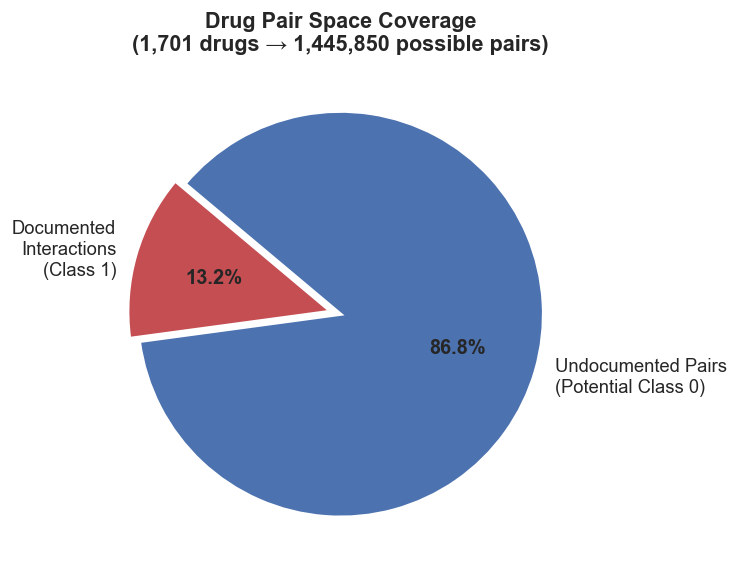

Only 13.2% of all possible pairs are documented as interactions.
This justifies the open-world assumption: unlisted pairs are treated as safe.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

labels  = ['Documented\nInteractions\n(Class 1)', 'Undocumented Pairs\n(Potential Class 0)']
sizes   = [len(df), n_possible - len(df)]
explode = (0.05, 0)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=[RED, BLUE], explode=explode,
    startangle=140, textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)

ax.set_title(
    f'Drug Pair Space Coverage\n'
    f'({n_unique:,} drugs → {n_possible:,} possible pairs)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot_03_pair_coverage.png', bbox_inches='tight')
plt.show()

print(f'Only {coverage_pct:.1f}% of all possible pairs are documented as interactions.')
print('This justifies the open-world assumption: unlisted pairs are treated as safe.')

---
## 5. Interaction Type Distribution

We parse the `Interaction Description` text to categorize each interaction into a mechanistic type. This reveals the biological pathways most represented in the dataset.

In [7]:
def classify_interaction(desc):
    d = desc.lower()
    if 'metabolism' in d and 'decrease' in d:            return 'Metabolism Decreased'
    if 'metabolism' in d and 'increase' in d:            return 'Metabolism Increased'
    if 'serum concentration' in d and 'increase' in d:   return 'Serum Conc. Increased'
    if 'serum concentration' in d and 'decrease' in d:   return 'Serum Conc. Decreased'
    if 'risk or severity of adverse effects' in d:       return 'Adverse Effects Risk'
    if 'cns depressant' in d or 'central nervous system depressant' in d:
                                                          return 'CNS Depressant Activity'
    if 'photosensitiz' in d:                              return 'Photosensitizing Activity'
    if 'excretion' in d and 'decrease' in d:             return 'Excretion Decreased'
    if 'excretion' in d and 'increase' in d:             return 'Excretion Increased'
    if 'hypoglycemic' in d or 'hypotensive' in d:        return 'BP / Blood Sugar Effect'
    if 'qtc' in d or 'qt-prolonging' in d or 'arrhythmia' in d:
                                                          return 'Cardiac Arrhythmia Risk'
    if 'bleeding' in d or 'anticoagulant' in d:          return 'Bleeding Risk'
    return 'Other'

df['Interaction_Type'] = df['Interaction Description'].apply(classify_interaction)
type_counts = df['Interaction_Type'].value_counts()
print(type_counts)

Interaction_Type
Adverse Effects Risk         60722
Metabolism Decreased         34313
Other                        28277
Serum Conc. Increased        24375
BP / Blood Sugar Effect      11122
Serum Conc. Decreased        10308
Cardiac Arrhythmia Risk       6582
CNS Depressant Activity       5454
Metabolism Increased          5000
Bleeding Risk                 3521
Excretion Decreased           1824
Excretion Increased             32
Photosensitizing Activity       11
Name: count, dtype: int64


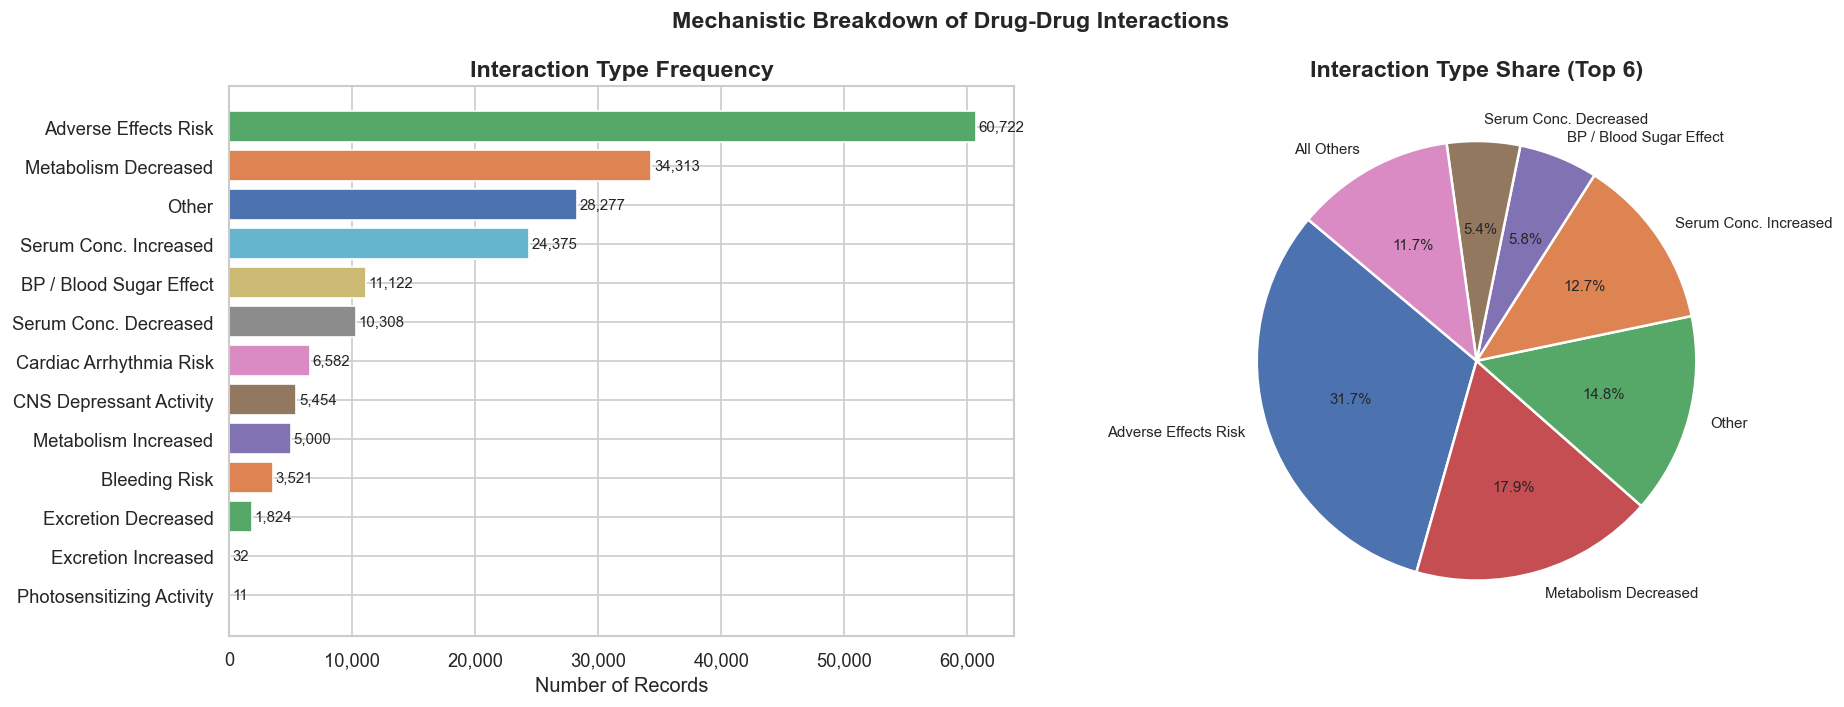

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1],
               color=COLORS[:len(type_counts)], edgecolor='white')
ax.set_title('Interaction Type Frequency', fontweight='bold')
ax.set_xlabel('Number of Records')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, type_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

# Pie chart (top 6 + Other)
ax2 = axes[1]
top6   = type_counts.head(6)
others = type_counts.iloc[6:].sum()
pie_data   = list(top6.values) + [others]
pie_labels = list(top6.index) + ['All Others']
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
        colors=COLORS[:7], startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 9})
ax2.set_title('Interaction Type Share (Top 6)', fontweight='bold')

plt.suptitle('Mechanistic Breakdown of Drug-Drug Interactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_interaction_types.png', bbox_inches='tight')
plt.show()

---
## 6. Interaction Description Length Distribution

Since descriptions follow a templated format, their lengths cluster tightly. This confirms the text follows structured patterns rather than free-form clinical notes.

Description length statistics:
count    191541.0
mean         89.8
std          15.9
min          58.0
25%          76.0
50%          92.0
75%         102.0
max         195.0
Name: Desc_Length, dtype: float64


C:\Users\devin\AppData\Local\Temp\ipykernel_8336\3584347581.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top6, x='Desc_Length', y='Interaction_Type',


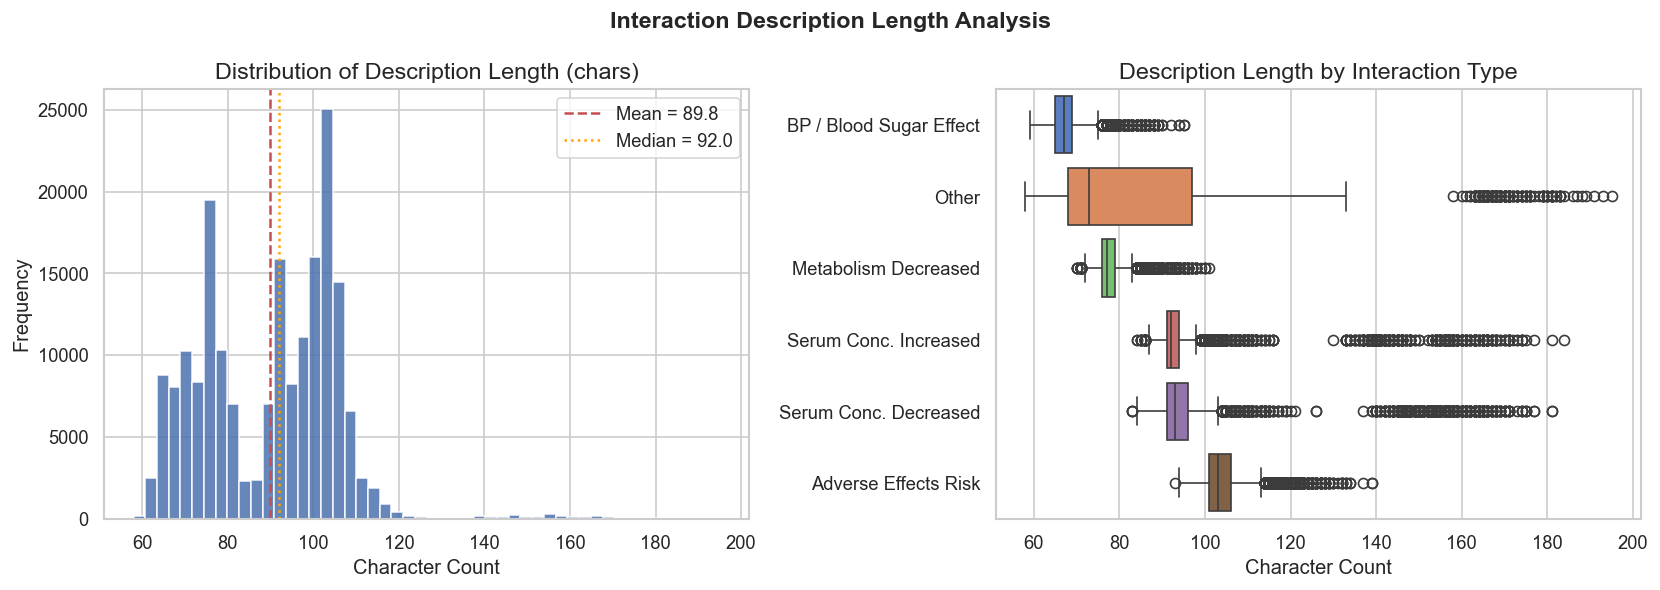


Insight: Tight distribution (std ≈ 16 chars) confirms descriptions follow
a templated format — useful for regex-based feature extraction later.


In [9]:
df['Desc_Length'] = df['Interaction Description'].str.len()

print('Description length statistics:')
print(df['Desc_Length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df['Desc_Length'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df['Desc_Length'].mean(), color=RED, linestyle='--',
           linewidth=1.5, label=f"Mean = {df['Desc_Length'].mean():.1f}")
ax.axvline(df['Desc_Length'].median(), color='orange', linestyle=':',
           linewidth=1.5, label=f"Median = {df['Desc_Length'].median():.1f}")
ax.set_title('Distribution of Description Length (chars)')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()

# Box plot by top 6 interaction types
ax2 = axes[1]
top6_types = type_counts.head(6).index.tolist()
df_top6 = df[df['Interaction_Type'].isin(top6_types)]
order = df_top6.groupby('Interaction_Type')['Desc_Length'].median().sort_values().index
sns.boxplot(data=df_top6, x='Desc_Length', y='Interaction_Type',
            order=order, palette='muted', ax=ax2)
ax2.set_title('Description Length by Interaction Type')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('')

plt.suptitle('Interaction Description Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_desc_length.png', bbox_inches='tight')
plt.show()

print('\nInsight: Tight distribution (std ≈ 16 chars) confirms descriptions follow')
print('a templated format — useful for regex-based feature extraction later.')

---
## 7. Drug Appearance Frequency — Distribution Shape

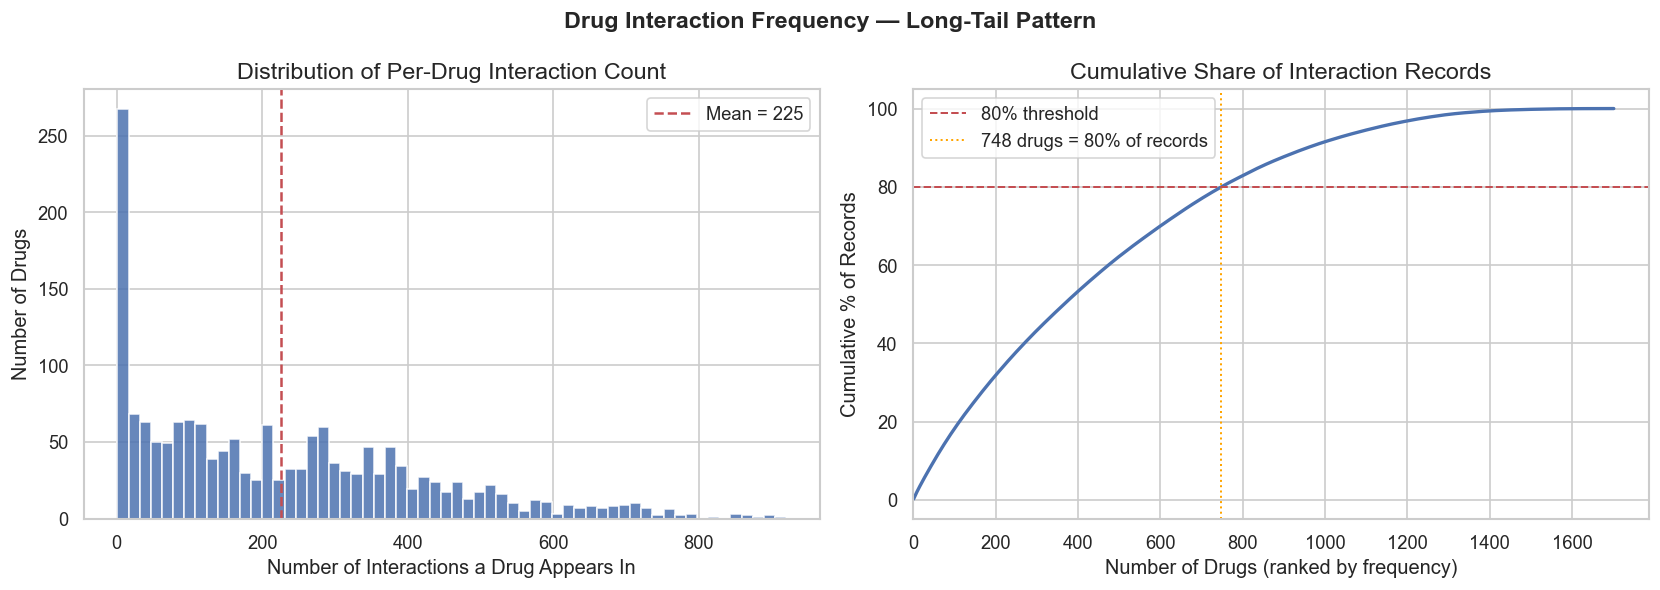


Insight: 748 drugs (44.0% of all drugs) account for
80% of all recorded interactions — a classic long-tail distribution.
A small set of enzyme inducers/inhibitors dominate the interaction landscape.


In [10]:
drug_freq = all_drugs.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of how many interactions each drug has
ax = axes[0]
ax.hist(drug_freq.values, bins=60, color=BLUE, edgecolor='white', alpha=0.85)
ax.set_title('Distribution of Per-Drug Interaction Count')
ax.set_xlabel('Number of Interactions a Drug Appears In')
ax.set_ylabel('Number of Drugs')
ax.axvline(drug_freq.mean(), color=RED, linestyle='--',
           linewidth=1.5, label=f'Mean = {drug_freq.mean():.0f}')
ax.legend()

# Cumulative distribution (how many drugs account for 80% of records)
ax2 = axes[1]
sorted_freq = drug_freq.sort_values(ascending=False)
cumsum_pct  = sorted_freq.cumsum() / sorted_freq.sum() * 100
ax2.plot(range(1, len(cumsum_pct)+1), cumsum_pct.values, color=BLUE, linewidth=2)
ax2.axhline(80, color=RED, linestyle='--', linewidth=1.2, label='80% threshold')
# Find how many drugs reach 80%
n_80 = (cumsum_pct <= 80).sum()
ax2.axvline(n_80, color='orange', linestyle=':', linewidth=1.2,
            label=f'{n_80} drugs = 80% of records')
ax2.set_title('Cumulative Share of Interaction Records')
ax2.set_xlabel('Number of Drugs (ranked by frequency)')
ax2.set_ylabel('Cumulative % of Records')
ax2.legend()
ax2.set_xlim(0)

plt.suptitle('Drug Interaction Frequency — Long-Tail Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_drug_freq_dist.png', bbox_inches='tight')
plt.show()

print(f'\nInsight: {n_80} drugs ({n_80/n_unique*100:.1f}% of all drugs) account for')
print('80% of all recorded interactions — a classic long-tail distribution.')
print('A small set of enzyme inducers/inhibitors dominate the interaction landscape.')

---
## 8. Feature Engineering Preview — Why Morgan Fingerprints?

The dataset has drug *names* and *text descriptions*, neither of which classical ML can consume directly. We will retrieve SMILES strings from PubChem and convert them to **Morgan Fingerprints** (binary circular fingerprints), which encode the structural neighborhood of each atom as a fixed-length binary vector.

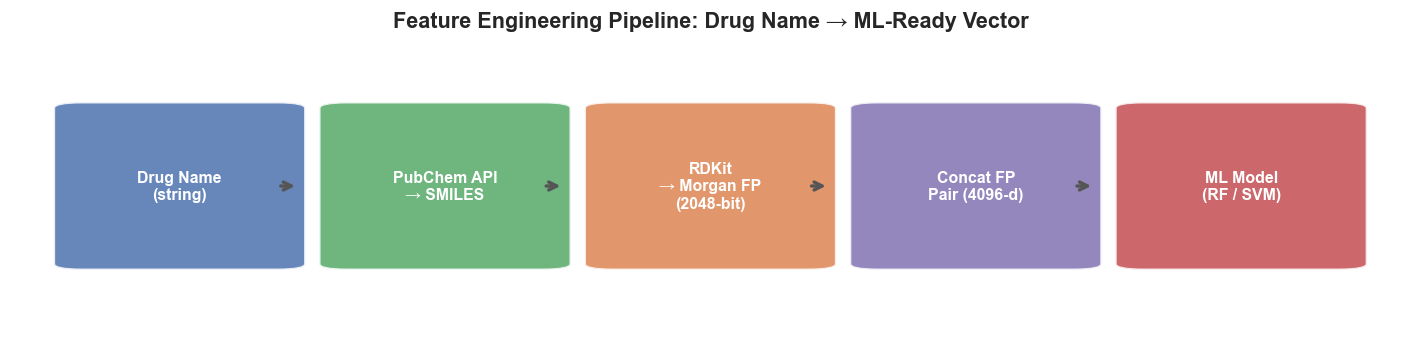

In [12]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

pipeline_steps = [
    ('Drug Name\n(string)', BLUE),
    ('PubChem API\n→ SMILES', '#55A868'),
    ('RDKit\n→ Morgan FP\n(2048-bit)', '#DD8452'),
    ('Concat FP\nPair (4096-d)', '#8172B3'),
    ('ML Model\n(RF / SVM)', RED),
]

n = len(pipeline_steps)
box_w, box_h = 0.14, 0.55
y_center = 0.5
gap = (1 - n * box_w) / (n + 1)

for i, (label, color) in enumerate(pipeline_steps):
    x = gap + i * (box_w + gap) + box_w / 2
    fancy = mpatches.FancyBboxPatch(
        (x - box_w/2, y_center - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.02', linewidth=1.5,
        edgecolor='white', facecolor=color, alpha=0.85,
        transform=ax.transAxes
    )
    ax.add_patch(fancy)
    ax.text(x, y_center, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='white')
    if i < n - 1:
        ax.annotate('', xy=(x + box_w/2 + gap*0.3, y_center),
                    xytext=(x + box_w/2, y_center),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('Feature Engineering Pipeline: Drug Name → ML-Ready Vector',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('plot_07_pipeline_diagram.png', bbox_inches='tight')
plt.show()

---
## 9. EDA Summary

| Finding | Implication for Modeling |
|---|---|
| 191,541 documented interactions, 0 missing values | Clean dataset, no imputation needed |
| Only Class 1 exists in raw data | Must generate Class 0 via random negative sampling |
| 13.25% pair coverage out of ~1.45M possible | Open-world assumption is justified |
| Long-tail drug frequency distribution | A few drugs (enzyme inducers) dominate; model must generalize across rare drugs too |
| "Adverse Effects Risk Increased" is largest category (31.7%) | Dataset skewed toward pharmacodynamic over pharmacokinetic interactions |
| Description length is tightly distributed (mean ≈ 90 chars) | Templated language; structural (SMILES) features more informative than raw text |
| 4096-d Morgan fingerprint pair vector | High-dimensional sparse input suits Random Forest and SVM well |

In [13]:
print('=== EDA COMPLETE ===')
print(f'Total records       : {len(df):,}')
print(f'Unique drugs         : {n_unique:,}')
print(f'Possible pairs       : {n_possible:,}')
print(f'Dataset coverage     : {coverage_pct:.2f}%')
print(f'Interaction types    : {df["Interaction_Type"].nunique()}')
print(f'Missing values       : {df.isnull().sum().sum()}')
print()
print('Plots saved:')
for i, name in enumerate([
    'plot_01_class_distribution.png',
    'plot_02_top_drugs.png',
    'plot_03_pair_coverage.png',
    'plot_04_interaction_types.png',
    'plot_05_desc_length.png',
    'plot_06_drug_freq_dist.png',
    'plot_07_pipeline_diagram.png',
], 1):
    print(f'  [{i}] {name}')

=== EDA COMPLETE ===
Total records       : 191,541
Unique drugs         : 1,701
Possible pairs       : 1,445,850
Dataset coverage     : 13.25%
Interaction types    : 13
Missing values       : 0

Plots saved:
  [1] plot_01_class_distribution.png
  [2] plot_02_top_drugs.png
  [3] plot_03_pair_coverage.png
  [4] plot_04_interaction_types.png
  [5] plot_05_desc_length.png
  [6] plot_06_drug_freq_dist.png
  [7] plot_07_pipeline_diagram.png
